# Python Bootcamp Day 3:
## Lecture 2: Timeseries & Pandas

We will continue our work with timeseries data by producing some plots based on our reformatted wind speed measurements. We will use these measurements to answer questions like "what month has the strongest average winds" and "how often are winds so weak that they don't spin the turbine".

### Goals for the lesson:
- Learn how to analyze the data 
- Learn how to make some simple plots of the data


Reminder:
<br/><font color='blue'>* Blue text indicates activities that you should complete as a student
<br/><font color='red'>* Red text indicates extra challenge questions 

In [2]:
### Import libraries / packages
from datetime import datetime  # for some datetime manipulations
import numpy as np # for data storage and math
import pandas as pd # for data storage and timeseries math
import matplotlib.pyplot as plt # for plotting

# 1. Read in data from previous lesson
We saved our nicely reformatted DataFrame from the previous lesson as a `.pkl` file with a different name, `reformatted_lidar_winds.pkl`. Let's start by loading that into a DataFrame and making sure it looks like we remember.

In [22]:
df = pd.read_pickle("../Lecture_1_pandas_1/reformatted_lidar_winds.pkl")

After running the command above, take a look at our DataFrame so we remember how it is structured:

In [23]:
df

,wspd18m,wspd38m,wspd58m,wspd78m,wspd98m,wspd118m,wspd138m,wspd158m,wspd178m,wspd198m
timestamp,,,,,,,,,,
2019-08-12 00:00:00,7.2923,7.6785,7.6968,7.8280,7.8013,7.8933,7.8635,7.8858,7.9044,NaN
2019-08-12 00:10:00,7.8613,8.0330,8.0225,7.9279,7.9980,7.9306,8.1698,8.1405,8.0702,8.0487
2019-08-12 00:20:00,7.7594,7.9883,8.0180,8.1314,8.0906,8.1408,8.1291,8.0939,8.2030,8.1353
2019-08-12 00:30:00,7.4891,7.7554,7.7973,7.9551,7.9063,7.9964,7.9652,8.0749,8.0105,8.0792
2019-08-12 00:40:00,7.8829,8.0248,8.1332,8.1741,7.9927,8.1230,8.0443,8.1074,8.1969,8.1296
...,...,...,...,...,...,...,...,...,...,...
2021-03-21 23:10:00,1.7978,1.9557,2.0617,1.9270,1.3744,1.0722,0.9203,0.9038,0.9421,1.2546
2021-03-21 23:20:00,2.6771,2.8746,2.8993,2.9530,2.9098,2.6337,2.1869,1.7314,1.5436,1.6571
2021-03-21 23:30:00,3.2416,3.4077,3.5611,3.5823,3.5930,3.3885,2.9375,2.4509,2.2373,2.2883


# 2. Processing the data

Now that our data is nicely formatted, we can begin to ask questions. For example, what is the average wind speed at every height? To get the average wind speed across all timesteps, run `df.mean()`. This function averages along every **column!**

In [17]:
df.mean()

wspd18m      8.445270
wspd38m      8.992000
wspd58m      9.415993
wspd78m      9.729263
wspd98m      9.956969
wspd118m    10.147648
wspd138m    10.291444
wspd158m    10.410221
wspd178m    10.507574
wspd198m    10.587666
dtype: float64

Instead of selecting all timestamps, we can also subselect data by characteristics. For example, we can subselect all data in September. Note, this grabs data in *both* September 2019 *and* September 2020.

In [24]:
df[df.index.month == 9]

,wspd18m,wspd38m,wspd58m,wspd78m,wspd98m,wspd118m,wspd138m,wspd158m,wspd178m,wspd198m
timestamp,,,,,,,,,,
2019-09-01 00:00:00,3.2105,3.2385,3.3626,3.7104,4.1178,4.6203,5.0136,5.3203,5.5163,5.6751
2019-09-01 00:10:00,3.3964,3.4400,3.5732,3.8556,4.3204,4.8156,5.2021,5.4885,5.6509,5.8073
2019-09-01 00:20:00,3.6487,3.6850,3.7574,3.9230,4.2971,4.7130,5.2817,5.7442,6.0274,6.2620
2019-09-01 00:30:00,3.6954,3.8106,3.8466,4.0392,4.4134,4.8945,5.4744,5.9791,6.3216,6.7377
2019-09-01 00:40:00,3.8427,3.8364,3.9178,4.1122,4.5196,4.9611,5.4682,5.9173,6.4331,7.1283
...,...,...,...,...,...,...,...,...,...,...
2020-09-30 23:10:00,10.9256,11.5187,11.4358,11.9205,12.0746,12.1553,11.9714,12.0186,12.0909,12.2526
2020-09-30 23:20:00,11.2253,12.0756,12.0432,12.5301,12.4020,12.3580,12.6023,12.4554,12.5982,12.5310
2020-09-30 23:30:00,10.7675,11.4955,11.7748,11.8653,11.9229,12.0874,12.1902,12.2825,12.3476,12.5317


You can also grab data from *only* September 2020.

In [25]:
df[(df.index.month == 9) & (df.index.year == 2020)]

,wspd18m,wspd38m,wspd58m,wspd78m,wspd98m,wspd118m,wspd138m,wspd158m,wspd178m,wspd198m
timestamp,,,,,,,,,,
2020-09-01 00:00:00,7.4121,7.5442,7.6316,7.7129,7.7869,7.7355,7.8697,7.9952,7.9353,7.9827
2020-09-01 00:10:00,7.6411,7.7939,7.7469,7.8915,7.7785,7.7956,7.9123,7.8311,7.8518,7.9834
2020-09-01 00:20:00,7.1965,7.3810,7.6062,7.5653,7.7067,7.7435,7.8671,7.8824,7.7973,7.8998
2020-09-01 00:30:00,7.8957,8.0605,8.0568,8.1648,8.3873,8.4980,8.5168,8.4518,8.6610,8.5862
2020-09-01 00:40:00,8.0709,8.3440,8.5717,8.5766,8.5445,8.6061,8.6648,8.7680,8.6943,8.8744
...,...,...,...,...,...,...,...,...,...,...
2020-09-30 23:10:00,10.9256,11.5187,11.4358,11.9205,12.0746,12.1553,11.9714,12.0186,12.0909,12.2526
2020-09-30 23:20:00,11.2253,12.0756,12.0432,12.5301,12.4020,12.3580,12.6023,12.4554,12.5982,12.5310
2020-09-30 23:30:00,10.7675,11.4955,11.7748,11.8653,11.9229,12.0874,12.1902,12.2825,12.3476,12.5317


We can find the average wind speeds in September 2020 by running `.mean()` on the data that we subselect.

In [26]:
df[(df.index.month == 9) & (df.index.year == 2020)].mean()

wspd18m     6.898349
wspd38m     7.353087
wspd58m     7.683202
wspd78m     7.964463
wspd98m     8.164553
wspd118m    8.329269
wspd138m    8.448159
wspd158m    8.540355
wspd178m    8.602126
wspd198m    8.665282
dtype: float64

<font color='blue'> Is the average wind speed in September 2020 higher or lower than the average over the whole dataset? How much higher/lower is it at 98m? </font>

### Visualizing the data

So far, we have been looking at average wind speed behavior. But how do winds vary over time? Let's plot 138 m winds.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,3))

ax.plot(df.index, df['wspd138m'])

ax.set_ylabel("Wind Speed [m/s]", fontsize=12)
ax.set_xlabel("Date", fontsize=12)

plt.show()

We can see that winds at any particular time can be as strong as 30 m/s or as weak as 0 m/s. Let's smooth this time series by averaging winds over every week. More information on the `pandas` resample function can be found [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html), but in short this function breaks up the data into shorter chunks (in the example below, each chunk is a week long) and then applies some function separately to each chunk (below, the function is `.mean()`).

In [ ]:
weekly_winds = df.resample("W").mean() # note the "W" stands for 'week'

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8,3))

ax.plot(df.index, df['wspd138m'], color='blue') # the original data, in blue
ax.plot(weekly_winds.index, weekly_winds['wspd138m'], color='orange') # the weekly averages, in orange

ax.set_ylabel("Wind Speed [m/s]", fontsize=12)
ax.set_xlabel("Date", fontsize=12)

plt.show()

<font color=blue> In the original data, we noticed that the wind can be as strong as 30 m/s or as weak as 0 m/s. What are the maximum and minimum **weekly average** wind speeds? </font>

### Bonus: Adding a new column to your Dataframe

What if we want to add a column of the average windspeed at all altitudes? It only requires 1 line of code!

In [ ]:
df['avg_wspd'] = df.mean(axis=1) # axis=0 is mean over all rows, axis=1 is mean over all columns

In [ ]:
df

# 3. Asking science questions

### What month has the strongest average winds?
Now that we've seen how to subset and visualize the data, let's try asking a more complex question. Our analysis task is to get the average wind speed per month. Our visualization task will then be to either plot the output so we can look for the highest peak or compute the maximum value.

To get the average wind speed per month, we're going to use a nifty function called `.groupby()`. Like `resample`, this will let us split the data into chunks and then apply some function to each chunk. But unlike `resample`, `groupby` lets us use chunks that are discontinuous in time. Let's see the difference when we try to get the average wind speed by month.

In [ ]:
resample_monthly_average = df.resample('ME').mean() # 'ME' stands for month end; the label will be the last day of each month
resample_monthly_average


,wspd18m,wspd38m,wspd58m,wspd78m,wspd98m,wspd118m,wspd138m,wspd158m,wspd178m,wspd198m
timestamp,,,,,,,,,,
2019-08-31,6.949480,7.219722,7.395140,7.531078,7.653481,7.792890,7.896601,8.001313,8.096509,8.183703
2019-09-30,7.319864,7.724898,8.007597,8.230970,8.413781,8.584529,8.734026,8.859340,8.964256,9.048661
2019-10-31,9.504249,10.091569,10.479572,10.799840,11.036784,11.247259,11.416193,11.555274,11.675615,11.781411
2019-11-30,9.721114,10.103554,10.325737,10.478630,10.586569,10.683515,10.769859,10.866306,10.945340,11.041701
2019-12-31,9.928392,10.326228,10.580167,10.785156,10.918350,10.995093,11.104547,11.187919,11.276127,11.356460
2020-01-31,9.685607,10.191281,10.529980,10.782113,11.001050,11.272931,11.422747,11.549034,11.667181,11.751505
2020-02-29,8.424041,8.964315,9.338868,9.607896,9.802103,10.016773,10.162692,10.287391,10.376625,10.480394
2020-03-31,8.896685,9.667947,10.205790,10.690040,11.046382,11.339173,11.560321,11.759382,11.904567,11.943258
2020-04-30,8.839850,9.743150,10.438278,10.989358,11.387217,11.695230,11.942472,12.138278,12.292561,12.432175


In the output above, notice that we have an average for each month in each year. Instead, what we want is the average for each month over all years, so the November average would be over November of 2019 and 2020 combined. This is what `groupby` allows us to do:

In [29]:
groupby_monthly_average = df.groupby(df.index.month).mean()
groupby_monthly_average

,wspd18m,wspd38m,wspd58m,wspd78m,wspd98m,wspd118m,wspd138m,wspd158m,wspd178m,wspd198m
timestamp,,,,,,,,,,
1,9.708095,10.116588,10.376438,10.559331,10.704044,10.861472,10.960880,11.044689,11.117964,11.168679
2,9.108928,9.594812,9.932097,10.134247,10.310296,10.496783,10.638835,10.770037,10.880936,10.998357
3,9.166847,9.883095,10.379830,10.822073,11.129312,11.400051,11.606979,11.785684,11.916237,11.972273
4,8.839850,9.743150,10.438278,10.989358,11.387217,11.695230,11.942472,12.138278,12.292561,12.432175
5,8.066996,9.190687,10.178475,10.824633,11.365879,11.721737,11.969079,12.133783,12.234776,12.297339
6,6.190969,7.091692,7.838511,8.417667,8.759420,8.989876,9.088251,9.168461,9.221068,9.253748
7,5.976314,6.490908,7.017166,7.377559,7.649542,7.849324,7.985666,8.076526,8.126966,8.151367
8,6.685177,7.073878,7.336588,7.540131,7.708618,7.868998,7.997798,8.109030,8.217007,8.297526
9,7.109131,7.539512,7.846158,8.099675,8.291662,8.460196,8.594827,8.704179,8.788119,8.862153


Now the timestamp has been converted to a number that represents each of the calendar months, and the average per month is an aggregate over all years in the dataset.


<font color='blue'>Plot `groupby_monthly_average`, with timestamp on the x-axis and wspd98m on the y-axis, to see which month has the highest average wind speed.

### <font color='red'>How often are winds so weak that they can't spin a wind turbine?
Wind turbines have a minimum speed; if the wind is slower than the minimum, it is not strong enough to turn the blades and generate electricity. The minimum speed varies depending on the turbine size and other factors but is usually around 10 mph, or 4-5 m/s. Let's get the fraction of time, for each month in the year, that the wind speed at 78m is fast enough to turn the turbine.


Hint (expand to read):
convert `df['wspd78m']` to a True/False array based on the wind speed relative to the threshold, then use `groupby` to get the number of times per month that condition is true

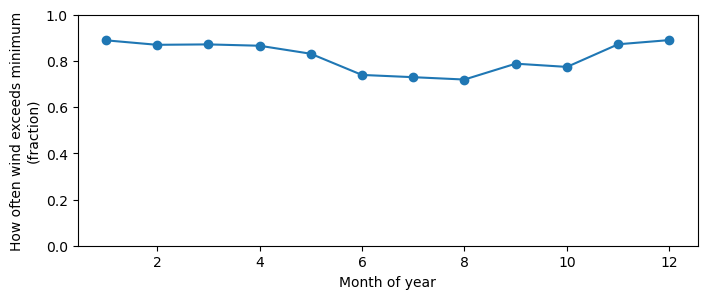

In [ ]:
# THIS IS THE SOLUTION

# Apply a condition to see when wind speed exceeds the threshold
min_windspeed = 4.5 # recall wind speed is in m/s
is_above_threshold = df['wspd78m'] > min_windspeed

# Use groupby to see how often wind is above the threshold per week
monthly_above_threshold = is_above_threshold.groupby(df.index.month).sum()

# To convert to a fraction, we need the total number of measurements per month
monthly_num_measurements = is_above_threshold.groupby(df.index.month).count()

# Get the fraction of measurements above the threshold each month
frac_above_threshold = monthly_above_threshold / monthly_num_measurements

# Plot the output by week
fig, ax = plt.subplots(1, 1, figsize=(8,3))
ax.plot(frac_above_threshold.index, frac_above_threshold, marker='o')
ax.set(xlabel='Month of year', ylabel='How often wind exceeds minimum\n(fraction)', ylim=(0, 1))
plt.show()